In [66]:
import matplotlib.pyplot as plt 
import json 
import numpy as np 
import pandas as pd
import os 

jsons_Ni_Mo = "Datasets"
stability_dicts = {}
EIS_dicts = {}
# Loop over all the datasets with the stability data
for json_file in os.listdir(jsons_Ni_Mo):
    if "Stability" in json_file:
        file_path = os.path.join(jsons_Ni_Mo, json_file)
        
        with open(file_path, 'r') as infile:
            stability_dict = json.load(infile)
        
        # Merge dictionaries
        stability_dicts.update(stability_dict)

# Loop over all the datasets with EIS data
for json_file in os.listdir(jsons_Ni_Mo):
    if "EIS" in json_file:
        file_path = os.path.join(jsons_Ni_Mo, json_file)
        
        with open(file_path, 'r') as infile:
            EIS_dict = json.load(infile)
        
        # Merge dictionaries
        EIS_dicts.update(EIS_dict)

print(len(EIS_dicts.keys()))


104


# Create df from json files

In [63]:

rows = []

for experiment, exp_data in stability_dicts.items():
    params = exp_data['ML optimization params']
    timestamp = exp_data["timestamp"]

    overpotentials_1 = exp_data['Cycling results']["Overpotentials at 1 mA/cm2"]
    overpotentials_10 = exp_data['Cycling results']["Overpotentials at 10 mA/cm2"]
    overpotentials_100 = exp_data['Cycling results']["Overpotentials at 100 mA/cm2"]

    measured_current_density_100 = exp_data['Cycling results']["Measured current density at 100 mA/cm2"]
    
    overpotentials_mean_1 = np.mean(overpotentials_1)
    overpotentials_mean_10 = np.mean(overpotentials_10)
    overpotentials_mean_100 = np.mean(overpotentials_100)
    current_density_100_mean = np.mean(measured_current_density_100)
    # Convert params to numeric where possible
    params_numeric = {
        k: float(v) if v is not None else np.nan
        for k, v in params.items()
    }
    
    row = {
        'experiment': experiment,
        'timestamp' : timestamp, 
        
        'OP @ -1 mA/cm2 mean (mV)' : abs(overpotentials_mean_1),
        'OP @ -10 mA/cm2 mean (mV)' : abs(overpotentials_mean_10),
        'OP @ -100 mA/cm2 mean (mV)' : abs(overpotentials_mean_100),
        'Measured I (mA/cm2) @ 100' : current_density_100_mean,
        **params_numeric
    }
    rows.append(row)


df_NiMo = pd.DataFrame(rows)

# Remove bad data (current density at -100 mA/cm² must be <= -1)
df_NiMo = df_NiMo[df_NiMo['Measured I (mA/cm2) @ 100'] <= -1] # Just remove erroneous data, where the current density measured is highly

# Sort by OP at -100 mA/cm2
df_NiMo = df_NiMo.sort_values(by='OP @ -100 mA/cm2 mean (mV)')

# Reset index
df_NiMo = df_NiMo.reset_index(drop=True)

df_NiMo['time_idx'] = df_NiMo.index

print(len(df_NiMo))


100


# Investigate degradation during cycling of the best catalysts at -1, -10 and -100 mA/cm2

-100.00054876378337 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_16_03__exp_43/Testing_data_06_05_2025_16_03__exp_43
-100.0012313095231 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_11_57__exp_85/Testing_data_11_05_2025_11_57__exp_85
-99.99735066824431 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_17_44__exp_44/Testing_data_06_05_2025_17_44__exp_44
-100.00268965101556 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/07_05_2025_00_39__exp_48/Testing_data_07_05_2025_00_39__exp_48
-99.99776477810627 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_18_10__exp_89/Testing_data_11_05_2025_18_10__exp_89


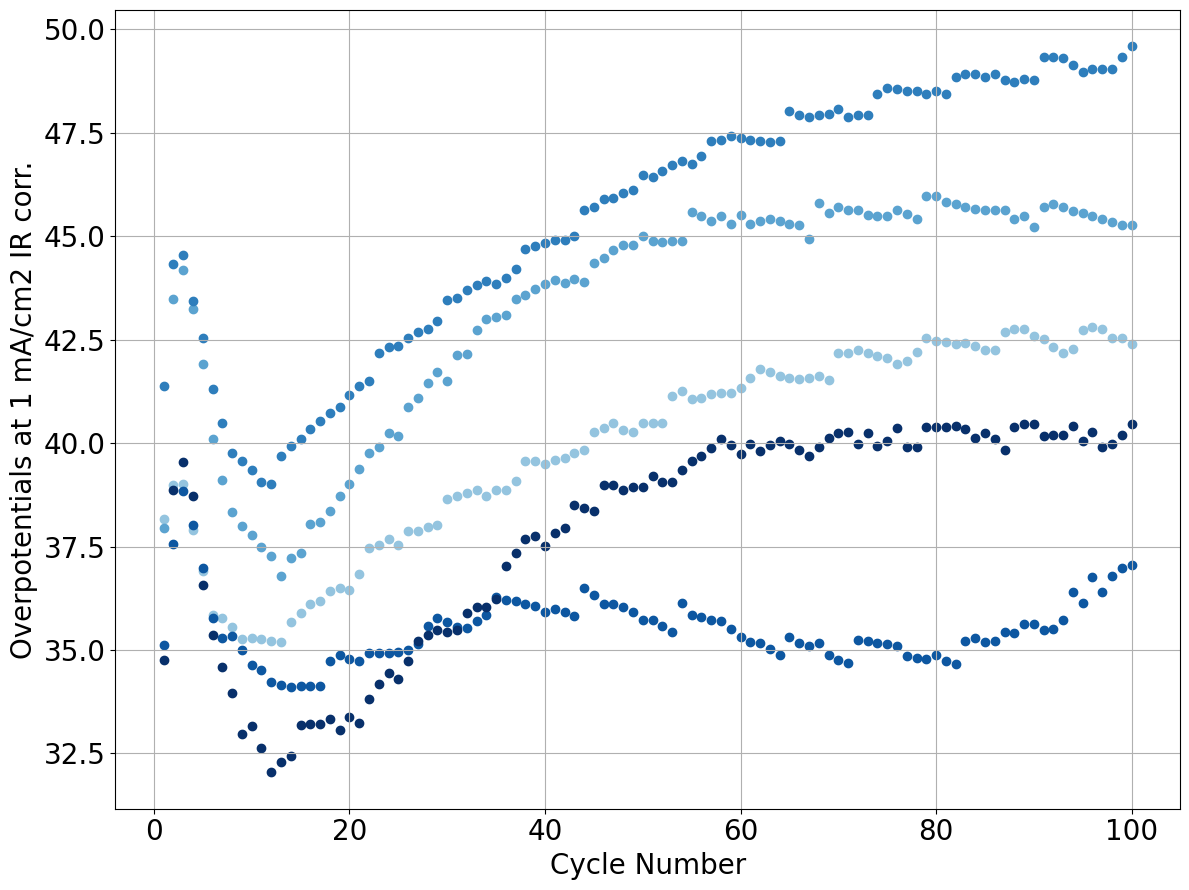

-100.00054876378337 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_16_03__exp_43/Testing_data_06_05_2025_16_03__exp_43
-100.0012313095231 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_11_57__exp_85/Testing_data_11_05_2025_11_57__exp_85
-99.99735066824431 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_17_44__exp_44/Testing_data_06_05_2025_17_44__exp_44
-100.00268965101556 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/07_05_2025_00_39__exp_48/Testing_data_07_05_2025_00_39__exp_48
-99.99776477810627 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_18_10__exp_89/Testing_data_11_05_2025_18_10__exp_89


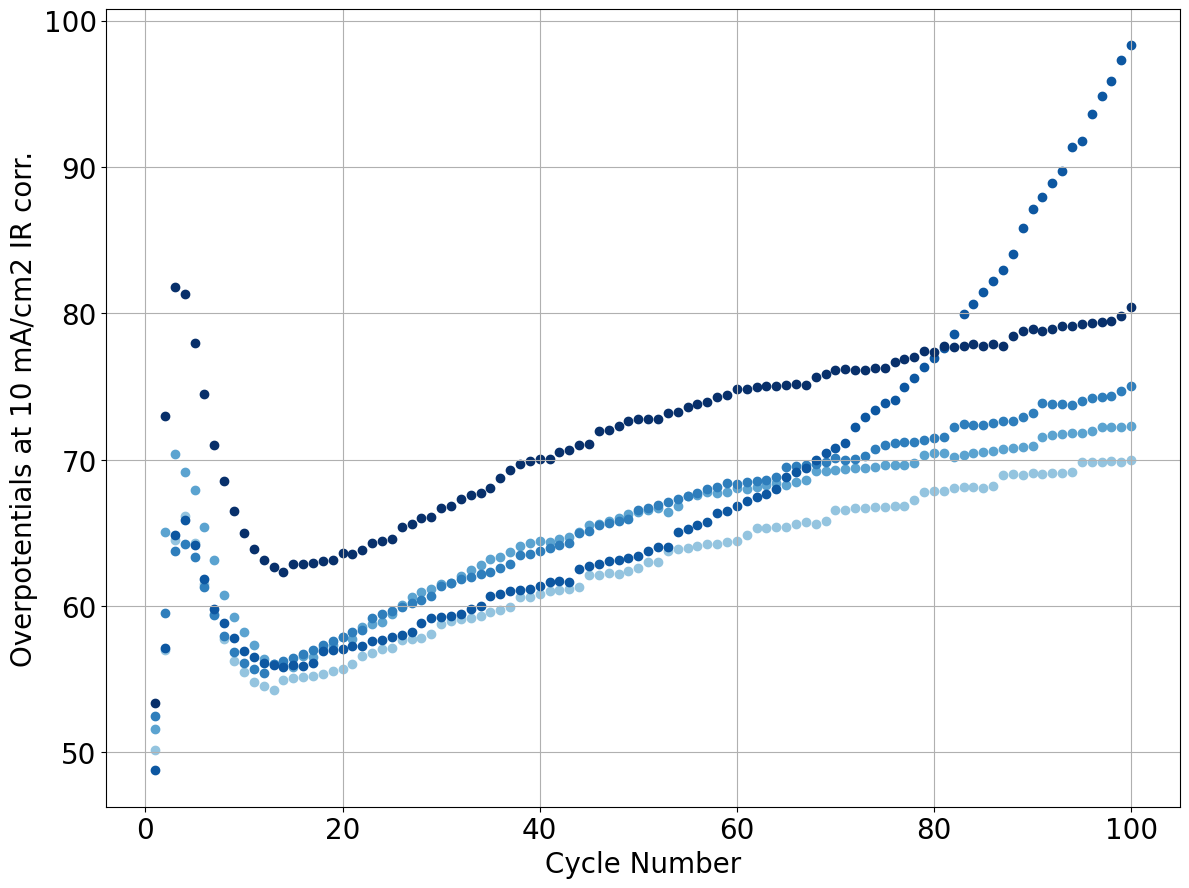

-100.00054876378337 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_16_03__exp_43/Testing_data_06_05_2025_16_03__exp_43
-100.0012313095231 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_11_57__exp_85/Testing_data_11_05_2025_11_57__exp_85
-99.99735066824431 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_17_44__exp_44/Testing_data_06_05_2025_17_44__exp_44
-100.00268965101556 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/07_05_2025_00_39__exp_48/Testing_data_07_05_2025_00_39__exp_48
-99.99776477810627 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_18_10__exp_89/Testing_data_11_05_2025_18_10__exp_89


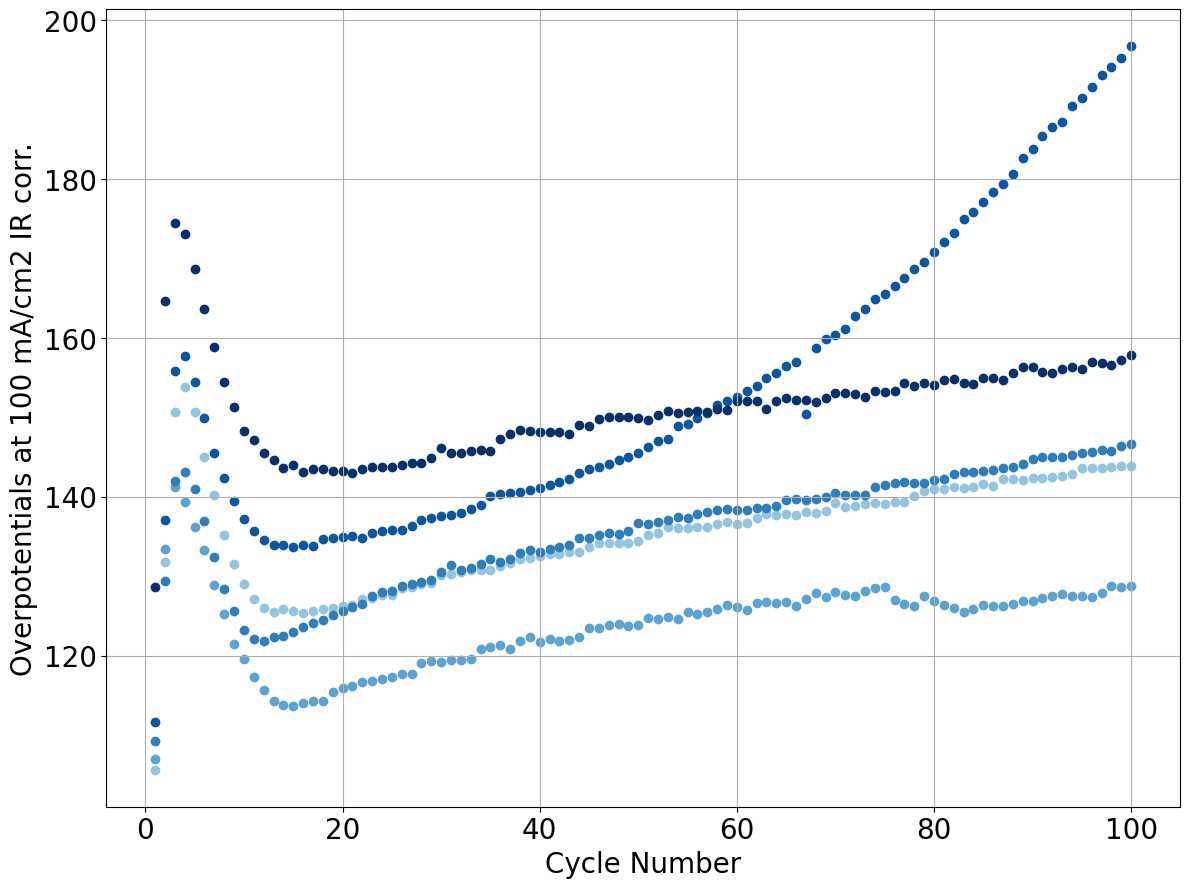

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# extract the experiments that you want to see. In our case the 10 samples iwth lowest overpotentials across the 100 scans
selected_exps = (
    df_NiMo.sort_values(by='OP @ -10 mA/cm2 mean (mV)')
    .head(5)['experiment']
    .tolist()
)
targets = ["Overpotentials at 1 mA/cm2", "Overpotentials at 10 mA/cm2", "Overpotentials at 100 mA/cm2"]

# Plot the targets that you want to see, i.e overpotentiaks
for target in targets:
    plt.figure(figsize=(12,9))

    blues = plt.cm.Blues(np.linspace(0.4, 1, len(selected_exps)))

    for color, experiment in zip(blues, selected_exps):

        data = stability_dicts[experiment]
        
        print(np.mean(data["Cycling results"]['Measured current density at 100 mA/cm2']), experiment)
        OP_100 = np.abs(data['Cycling results'][target])
        plt.scatter(np.arange(1 , 1 + len(OP_100)), OP_100, color=color)
        

    plt.xlabel("Cycle Number", fontsize=20)
    plt.ylabel(target + " IR corr.", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# EIS 

dict_keys(['Re_Z', 'Im_Z']) /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_Optimization_Jonas/Beta_5/29_05_2025_17_33__exp_24/Testing_data_29_05_2025_17_33__exp_24
dict_keys(['Re_Z', 'Im_Z']) /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/11_05_2025_11_57__exp_85/Testing_data_11_05_2025_11_57__exp_85
dict_keys(['Re_Z', 'Im_Z']) /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_Optimization_Jonas/Beta_5/29_05_2025_15_46__exp_23/Testing_data_29_05_2025_15_46__exp_23
dict_keys(['Re_Z', 'Im_Z']) /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_16_03__exp_43/Testing_data_06_05_2025_16_03__exp_43
dict_keys(['Re_Z', 'Im_Z']) /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_run_01_05_25/06_05_2025_17_44__exp_44/Testing_data_06_05_2025

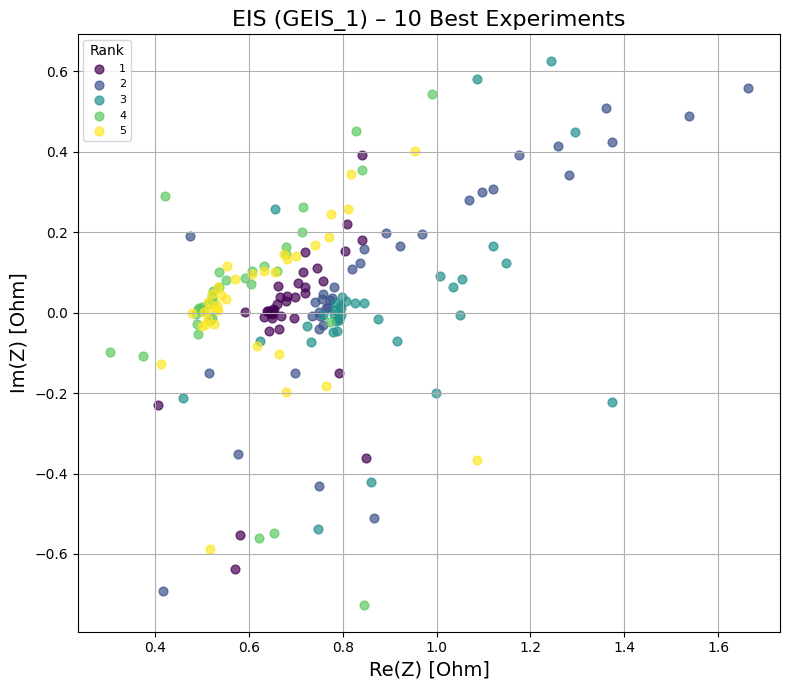

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Select 10 best experiments
selected_exps = (
    df_NiMo.sort_values(by='OP @ -100 mA/cm2 mean (mV)')
    .head(5)['experiment']
    .tolist()
)

plt.figure(figsize=(8, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(selected_exps)))

for i, (color, experiment) in enumerate(zip(colors, selected_exps)):
    data = EIS_dicts[experiment]
    GEIS_bef = data["GEIS_1"]
    print(data["GEIS_1"].keys(), experiment)
    Re = GEIS_bef["Re_Z"]
    Im = GEIS_bef["Im_Z"]

    plt.scatter(Re, Im, color=color, s=40, alpha=0.7, label=f"{i+1}")

plt.xlabel("Re(Z) [Ohm]", fontsize=14)
plt.ylabel("Im(Z) [Ohm]", fontsize=14)
plt.title("EIS (GEIS_1) – 10 Best Experiments", fontsize=16)

plt.grid(True)
plt.legend(title="Rank", fontsize=8)

plt.tight_layout()
plt.show()